# 4.bis. Modélisation supervisée et semi-supervisée (régression logistique sur embeddings)

Objectif : comparer une baseline supervisée entraînée uniquement sur les labels forts avec deux approches semi-supervisées prudentes :

- KMeans sélectif : clusters purs, méthode principale ;
- DBSCAN sélectif : alternative très sélective, orientée clusters denses et purs.

## Méthodologie corrigée

Le semi-supervisé précédent ajoutait tous les pseudo-labels KMeans, ce qui donnait trop de poids à des labels faibles parfois bruités.

La méthodologie corrigée est plus sélective :

- le test final contient uniquement des images fortement labellisées ;
- le clustering est réappris sans les images du test final ;
- les clusters sont nommés uniquement à partir des labels forts du train ;
- un cluster n'est utilisé que si sa pureté sur les labels forts du train est très élevée ;
- les pseudo-labels gardés sont faiblement pondérés ;
- la comparaison principale est faite en validation croisée, avec la sélection des clusters refaite à l'intérieur de chaque fold.

DBSCAN est ajouté comme comparaison car l'analyse non supervisée montre qu'il peut isoler un cluster `cancer` très pur. L'objectif est de vérifier si cette pureté locale se traduit en meilleures performances de classification.

In [1]:
# Imports
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

RANDOM_STATE = 42
OUTPUT_DIR = Path("data/processed")
FEATURES_PATH = OUTPUT_DIR / "resnet18_features.csv"
TEST_SIZE = 0.50

In [2]:
# Chargement des embeddings et séparation des jeux
features_df = pd.read_csv(FEATURES_PATH)
feature_columns = [col for col in features_df.columns if col.startswith("feature_")]

strong_df = features_df[features_df["label"].isin(["normal", "cancer"])].copy()
unknown_df = features_df[features_df["label"].eq("unknown")].copy()

print("Full dataset:", features_df.shape)
print("Strong labels:", strong_df.shape)
print("Unknown images:", unknown_df.shape)
display(strong_df["label"].value_counts())

Full dataset: (1506, 515)
Strong labels: (100, 515)
Unknown images: (1406, 515)


label
cancer    50
normal    50
Name: count, dtype: int64

## Split final

Le split final sert de comparaison simple et lisible. Il contient uniquement des labels forts. Les images `unknown` ne sont jamais utilisées pour évaluer les modèles.

Ce split n'est pas la preuve principale, car avec seulement 100 images fortement labellisées, un découpage unique peut être sensible au hasard. La validation croisée sera donc utilisée comme évaluation principale de la robustesse.

In [3]:
# Split final uniquement sur les labels forts
train_idx, test_idx = train_test_split(
    strong_df.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=strong_df["label"],
)

train_strong_df = features_df.loc[train_idx].copy()
test_strong_df = features_df.loc[test_idx].copy()

X_train_strong = train_strong_df[feature_columns].values
y_train_strong = train_strong_df["label"].values
X_test = test_strong_df[feature_columns].values
y_test = test_strong_df["label"].values

print("Strong train:", X_train_strong.shape)
display(pd.Series(y_train_strong).value_counts())
print("Strong test:", X_test.shape)
display(pd.Series(y_test).value_counts())

Strong train: (50, 512)


cancer    25
normal    25
Name: count, dtype: int64

Strong test: (50, 512)


normal    25
cancer    25
Name: count, dtype: int64

In [4]:
def make_classifier():
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    )


def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_cancer": f1_score(y_test, y_pred, pos_label="cancer", zero_division=0),
        "recall_cancer": recall_score(y_test, y_pred, pos_label="cancer", zero_division=0),
        "precision_cancer": precision_score(y_test, y_pred, pos_label="cancer", zero_division=0),
    }

    print(model_name)
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred, labels=["normal", "cancer"])
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["normal", "cancer"],
        yticklabels=["normal", "cancer"],
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(model_name)
    plt.show()

    return metrics, y_pred

supervised_strong_only
              precision    recall  f1-score   support

      cancer       0.86      0.96      0.91        25
      normal       0.95      0.84      0.89        25

    accuracy                           0.90        50
   macro avg       0.91      0.90      0.90        50
weighted avg       0.91      0.90      0.90        50



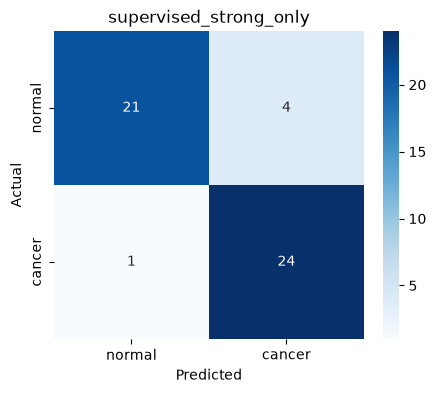

In [5]:
# Baseline supervisée
supervised_model = make_classifier()
supervised_model.fit(X_train_strong, y_train_strong)

supervised_metrics, supervised_pred = evaluate_model(
    supervised_model,
    X_test,
    y_test,
    "supervised_strong_only",
)

## Construction sélective des pseudo-labels

La fonction suivante construit un jeu semi-supervisé avec KMeans ou DBSCAN.

La logique est identique pour les deux méthodes :

1. On entraîne le clustering sur `train fort + unknown`.
2. On mesure la pureté des clusters uniquement avec les labels forts du train.
3. On garde seulement les clusters suffisamment purs.
4. On pseudo-labellise uniquement les images `unknown` appartenant aux clusters gardés.
5. On donne un faible poids aux pseudo-labels.

Pour DBSCAN, le cluster `-1` est ignoré car il correspond au bruit, pas à un cluster exploitable.

In [ ]:
def assign_clusters(df, feature_columns, method, **config):
    X = df[feature_columns].values

    if method == "kmeans":
        clustering_model = make_pipeline(
            StandardScaler(),
            KMeans(
                n_clusters=config["k"],
                random_state=RANDOM_STATE,
                n_init=10,
            ),
        )
        return clustering_model.fit_predict(X)

    if method == "dbscan":
        clustering_model = make_pipeline(
            StandardScaler(),
            DBSCAN(
                eps=config["eps"],
                min_samples=config["min_samples"],
            ),
        )
        return clustering_model.fit_predict(X)

    raise ValueError(f"Unknown clustering method: {method}")


def build_selective_pseudo_labels(
    train_strong_df,
    unknown_df,
    feature_columns,
    method,
    purity_threshold=0.95,
    min_labeled_per_cluster=2,
    pseudo_weight=0.01, # Voir l'analyse des poids pour les pseudo-labels à la fin du notebook
    mode="both",
    **cluster_config,
):
    pseudo_source_df = pd.concat([train_strong_df, unknown_df], axis=0).copy()
    pseudo_source_df["cluster_modeling"] = assign_clusters(
        pseudo_source_df,
        feature_columns,
        method=method,
        **cluster_config,
    )

    if method == "dbscan":
        pseudo_source_df = pseudo_source_df[pseudo_source_df["cluster_modeling"].ne(-1)].copy()

    train_with_clusters = pseudo_source_df[
        pseudo_source_df["label"].isin(["normal", "cancer"])
    ].copy()
    unknown_with_clusters = pseudo_source_df[pseudo_source_df["label"].eq("unknown")].copy()

    cluster_counts = pd.crosstab(
        train_with_clusters["cluster_modeling"],
        train_with_clusters["label"],
    )

    for label in ["cancer", "normal"]:
        if label not in cluster_counts.columns:
            cluster_counts[label] = 0

    cluster_counts = cluster_counts[["cancer", "normal"]]
    cluster_stats = cluster_counts.copy()
    cluster_stats["n_labeled"] = cluster_stats.sum(axis=1)
    cluster_stats["majority_label"] = cluster_counts.idxmax(axis=1)
    cluster_stats["purity"] = cluster_counts.max(axis=1) / cluster_stats["n_labeled"]

    selected_clusters = cluster_stats[
        (cluster_stats["n_labeled"] >= min_labeled_per_cluster)
        & (cluster_stats["purity"] >= purity_threshold)
    ].copy()

    if mode == "cancer_only":
        selected_clusters = selected_clusters[selected_clusters["majority_label"].eq("cancer")]

    cluster_to_label = selected_clusters["majority_label"].to_dict()
    cluster_to_purity = selected_clusters["purity"].to_dict()
    cluster_to_n = selected_clusters["n_labeled"].to_dict()

    unknown_with_clusters["pseudo_label"] = unknown_with_clusters["cluster_modeling"].map(cluster_to_label)
    unknown_with_clusters["cluster_purity"] = unknown_with_clusters["cluster_modeling"].map(cluster_to_purity)
    unknown_with_clusters["cluster_labeled_count"] = unknown_with_clusters["cluster_modeling"].map(cluster_to_n)

    pseudo_labeled_df = unknown_with_clusters.dropna(subset=["pseudo_label"]).copy()

    train_for_semi = train_with_clusters.copy()
    train_for_semi["training_label"] = train_for_semi["label"]
    train_for_semi["sample_weight"] = 1.0
    train_for_semi["pseudo_label"] = np.nan
    train_for_semi["cluster_purity"] = np.nan
    train_for_semi["cluster_labeled_count"] = np.nan

    pseudo_for_semi = pseudo_labeled_df.copy()
    pseudo_for_semi["training_label"] = pseudo_for_semi["pseudo_label"]
    pseudo_for_semi["sample_weight"] = pseudo_weight

    semi_train_df = pd.concat([train_for_semi, pseudo_for_semi], axis=0)

    return semi_train_df, pseudo_labeled_df, cluster_stats, selected_clusters

In [7]:
KMEANS_CONFIG = {
    "method": "kmeans",
    "k": 10,
    "purity_threshold": 0.95,
    "min_labeled_per_cluster": 2,
    "pseudo_weight": 0.01,
    "mode": "both",
}

DBSCAN_CONFIG = {
    "method": "dbscan",
    "eps": 21.5,
    "min_samples": 12,
    "purity_threshold": 0.95,
    "min_labeled_per_cluster": 2,
    "pseudo_weight": 0.01,
    "mode": "both",
}

MODEL_CONFIGS = {
    "kmeans_selective": KMEANS_CONFIG,
    "dbscan_selective": DBSCAN_CONFIG,
}

In [8]:
def fit_semi_supervised_model(train_strong_df, unknown_df, config, model_name):
    semi_train_df, pseudo_labeled_df, cluster_stats, selected_clusters = build_selective_pseudo_labels(
        train_strong_df,
        unknown_df,
        feature_columns,
        **config,
    )

    model = make_classifier()
    model.fit(
        semi_train_df[feature_columns].values,
        semi_train_df["training_label"].values,
        logisticregression__sample_weight=semi_train_df["sample_weight"].values,
    )

    metrics, predictions = evaluate_model(model, X_test, y_test, model_name)

    return {
        "model": model,
        "metrics": metrics,
        "predictions": predictions,
        "semi_train_df": semi_train_df,
        "pseudo_labeled_df": pseudo_labeled_df,
        "cluster_stats": cluster_stats,
        "selected_clusters": selected_clusters,
    }

kmeans_selective
semi_supervised_kmeans_selective
              precision    recall  f1-score   support

      cancer       0.86      0.96      0.91        25
      normal       0.95      0.84      0.89        25

    accuracy                           0.90        50
   macro avg       0.91      0.90      0.90        50
weighted avg       0.91      0.90      0.90        50



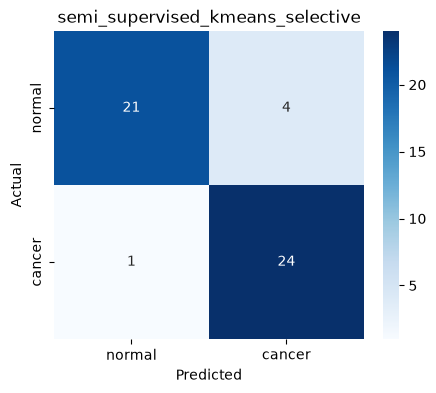

Selected clusters:


label,cancer,normal,n_labeled,majority_label,purity
cluster_modeling,,,,,
0,3,0,3,cancer,1.0
1,2,0,2,cancer,1.0
2,3,0,3,cancer,1.0
3,7,0,7,cancer,1.0
6,3,0,3,cancer,1.0
7,0,13,13,normal,1.0
8,0,8,8,normal,1.0


Pseudo-label counts:


pseudo_label
cancer    767
normal    199
Name: count, dtype: int64

Semi-supervised train shape: (1016, 521)


training_label
cancer    792
normal    224
Name: count, dtype: int64

sample_weight
0.01    966
1.00     50
Name: count, dtype: int64

dbscan_selective
semi_supervised_dbscan_selective
              precision    recall  f1-score   support

      cancer       0.86      0.96      0.91        25
      normal       0.95      0.84      0.89        25

    accuracy                           0.90        50
   macro avg       0.91      0.90      0.90        50
weighted avg       0.91      0.90      0.90        50



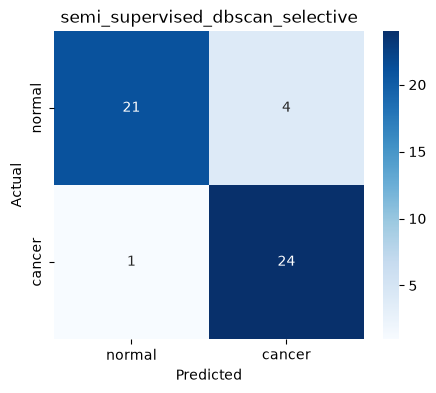

Selected clusters:


label,cancer,normal,n_labeled,majority_label,purity
cluster_modeling,,,,,
0,11,0,11,cancer,1.0


Pseudo-label counts:


pseudo_label
cancer    322
Name: count, dtype: int64

Semi-supervised train shape: (357, 521)


training_label
cancer    338
normal     19
Name: count, dtype: int64

sample_weight
0.01    322
1.00     35
Name: count, dtype: int64

In [9]:
# Semi-supervisé sélectif sur le split final : KMeans vs DBSCAN
semi_results = {}

for model_name, config in MODEL_CONFIGS.items():
    print("=" * 80)
    print(model_name)
    result = fit_semi_supervised_model(
        train_strong_df,
        unknown_df,
        config,
        f"semi_supervised_{model_name}",
    )
    semi_results[model_name] = result

    print("Selected clusters:")
    display(result["selected_clusters"])
    print("Pseudo-label counts:")
    display(result["pseudo_labeled_df"]["pseudo_label"].value_counts())
    print("Semi-supervised train shape:", result["semi_train_df"].shape)
    display(result["semi_train_df"]["training_label"].value_counts())
    display(result["semi_train_df"]["sample_weight"].value_counts())

In [10]:
# Vérification de fuite de données entre test final et trains semi-supervisés
test_paths = set(test_strong_df["path"])

for model_name, result in semi_results.items():
    semi_train_paths = set(result["semi_train_df"]["path"])
    leakage = test_paths.intersection(semi_train_paths)
    print(model_name, "- test images found in semi-supervised train:", len(leakage))

kmeans_selective - test images found in semi-supervised train: 0
dbscan_selective - test images found in semi-supervised train: 0


,model,accuracy,precision_macro,recall_macro,f1_macro,f1_cancer,recall_cancer,precision_cancer
0,supervised_strong_only,0.9,0.905844,0.9,0.899639,0.90566,0.96,0.857143
1,semi_supervised_kmeans_selective,0.9,0.905844,0.9,0.899639,0.90566,0.96,0.857143
2,semi_supervised_dbscan_selective,0.9,0.905844,0.9,0.899639,0.90566,0.96,0.857143


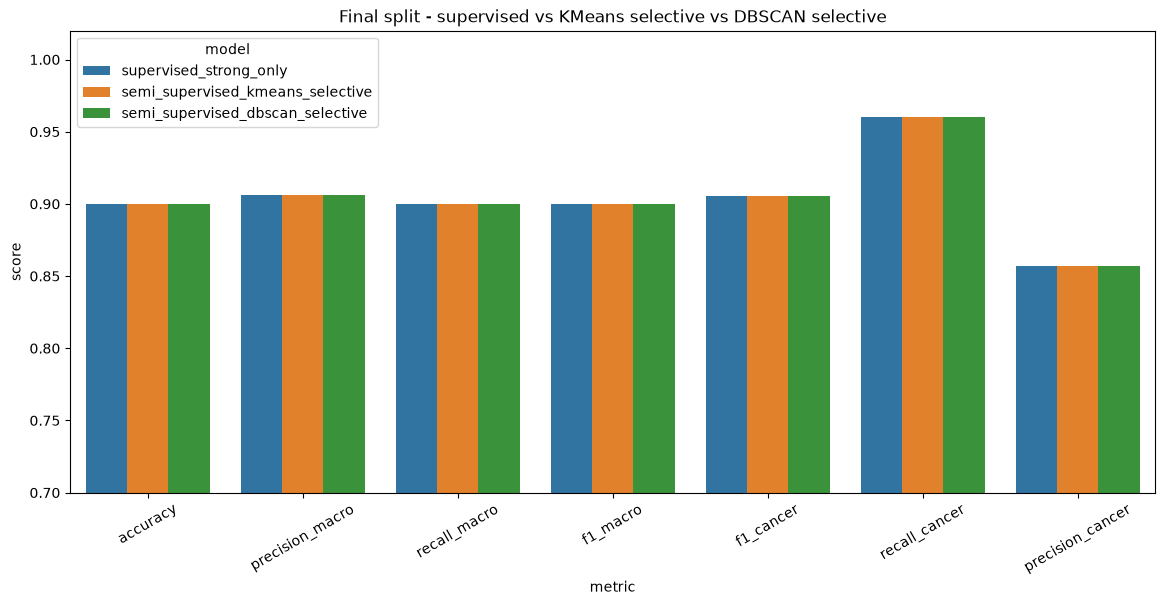

In [11]:
# Comparaison sur le split final
metrics_df = pd.DataFrame(
    [supervised_metrics]
    + [result["metrics"] for result in semi_results.values()]
)
display(metrics_df)

metrics_long = metrics_df.melt(
    id_vars="model",
    value_vars=[
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "f1_cancer",
        "recall_cancer",
        "precision_cancer",
    ],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(14, 6))
sns.barplot(data=metrics_long, x="metric", y="score", hue="model")
plt.ylim(0.7, 1.02)
plt.title("Final split - supervised vs KMeans selective vs DBSCAN selective")
plt.xticks(rotation=30)
plt.show()

### Interprétation du split final

Sur le split final 50/50, les modèles semi-supervisés n'améliorent pas la baseline supervisée. Les pseudo-labels ne dégradent pas les performances, mais le gain n'est pas visible sur ce découpage unique.

Ce résultat doit être interprété avec prudence, car le test set contient seulement 50 images. La validation croisée est donc plus pertinente pour juger la robustesse de la méthode.

In [12]:
prediction_comparison = test_strong_df[["path", "label"]].copy()
prediction_comparison["supervised_pred"] = supervised_pred

for model_name, result in semi_results.items():
    prediction_comparison[f"{model_name}_pred"] = result["predictions"]

for model_name in semi_results:
    prediction_comparison[f"same_as_supervised_{model_name}"] = (
        prediction_comparison["supervised_pred"]
        == prediction_comparison[f"{model_name}_pred"]
    )

display(prediction_comparison)

,path,label,supervised_pred,kmeans_selective_pred,dbscan_selective_pred,same_as_supervised_kmeans_selective,same_as_supervised_dbscan_selective
58,data\raw\avec_labels\normal\2794c549-1ec3-4d08...,normal,normal,normal,normal,True,True
22,data\raw\avec_labels\cancer\9973120d-7335-43da...,cancer,cancer,cancer,cancer,True,True
7,data\raw\avec_labels\cancer\2d662cc1-509b-4657...,cancer,cancer,cancer,cancer,True,True
63,data\raw\avec_labels\normal\4131a20d-a19d-4cd9...,normal,normal,normal,normal,True,True
23,data\raw\avec_labels\cancer\9c3a8bbd-8bdb-4fdc...,cancer,cancer,cancer,cancer,True,True
18,data\raw\avec_labels\cancer\7e3f6acd-c9cc-440e...,cancer,normal,normal,normal,True,True
33,data\raw\avec_labels\cancer\be3210d7-e2d1-4cc3...,cancer,cancer,cancer,cancer,True,True
10,data\raw\avec_labels\cancer\46587a13-4250-4d3e...,cancer,cancer,cancer,cancer,True,True
28,data\raw\avec_labels\cancer\ad5ff4c2-0fe6-4e8c...,cancer,cancer,cancer,cancer,True,True
65,data\raw\avec_labels\normal\42ba7707-26c1-42bc...,normal,cancer,cancer,cancer,True,True


### Diagnostic des prédictions

Cette table permet d'identifier les images pour lesquelles les modèles divergent. Elle sert au diagnostic qualitatif, mais la comparaison principale repose sur les métriques agrégées et la validation croisée.

In [13]:
def supervised_cv(strong_df, feature_columns, n_splits=5):
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    X = strong_df[feature_columns].values
    y = strong_df["label"].values
    results = []

    for fold, (train_pos, test_pos) in enumerate(skf.split(X, y), start=1):
        train_fold = strong_df.iloc[train_pos].copy()
        test_fold = strong_df.iloc[test_pos].copy()

        model = make_classifier()
        model.fit(train_fold[feature_columns].values, train_fold["label"].values)
        y_pred = model.predict(test_fold[feature_columns].values)

        results.append({
            "fold": fold,
            "model": "supervised_cv",
            "accuracy": accuracy_score(test_fold["label"], y_pred),
            "f1_macro": f1_score(test_fold["label"], y_pred, average="macro", zero_division=0),
            "f1_cancer": f1_score(test_fold["label"], y_pred, pos_label="cancer", zero_division=0),
            "recall_cancer": recall_score(test_fold["label"], y_pred, pos_label="cancer", zero_division=0),
            "precision_cancer": precision_score(test_fold["label"], y_pred, pos_label="cancer", zero_division=0),
            "n_pseudo": 0,
            "n_pseudo_cancer": 0,
            "n_pseudo_normal": 0,
            "n_selected_clusters": 0,
        })

    return pd.DataFrame(results)


def semi_supervised_selective_cv(
    strong_df,
    unknown_df,
    feature_columns,
    config,
    model_name,
    n_splits=5,
):
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    X = strong_df[feature_columns].values
    y = strong_df["label"].values
    results = []

    for fold, (train_pos, test_pos) in enumerate(skf.split(X, y), start=1):
        train_fold = strong_df.iloc[train_pos].copy()
        test_fold = strong_df.iloc[test_pos].copy()

        semi_train_fold, pseudo_labeled_fold, _, selected_clusters_fold = build_selective_pseudo_labels(
            train_fold,
            unknown_df,
            feature_columns,
            **config,
        )

        model = make_classifier()
        model.fit(
            semi_train_fold[feature_columns].values,
            semi_train_fold["training_label"].values,
            logisticregression__sample_weight=semi_train_fold["sample_weight"].values,
        )
        y_pred = model.predict(test_fold[feature_columns].values)

        pseudo_counts = pseudo_labeled_fold["pseudo_label"].value_counts()

        results.append({
            "fold": fold,
            "model": model_name,
            "accuracy": accuracy_score(test_fold["label"], y_pred),
            "f1_macro": f1_score(test_fold["label"], y_pred, average="macro", zero_division=0),
            "f1_cancer": f1_score(test_fold["label"], y_pred, pos_label="cancer", zero_division=0),
            "recall_cancer": recall_score(test_fold["label"], y_pred, pos_label="cancer", zero_division=0),
            "precision_cancer": precision_score(test_fold["label"], y_pred, pos_label="cancer", zero_division=0),
            "n_pseudo": len(pseudo_labeled_fold),
            "n_pseudo_cancer": pseudo_counts.get("cancer", 0),
            "n_pseudo_normal": pseudo_counts.get("normal", 0),
            "n_selected_clusters": len(selected_clusters_fold),
            "pseudo_weight": config["pseudo_weight"],
            "purity_threshold": config["purity_threshold"],
            "min_labeled_per_cluster": config["min_labeled_per_cluster"],
            "clustering_method": config["method"],
        })

    return pd.DataFrame(results)

In [14]:
# Validation croisée : comparaison principale
supervised_cv_df = supervised_cv(strong_df, feature_columns)

cv_dfs = [supervised_cv_df]
for model_name, config in MODEL_CONFIGS.items():
    cv_dfs.append(
        semi_supervised_selective_cv(
            strong_df,
            unknown_df,
            feature_columns,
            config=config,
            model_name=f"semi_supervised_{config['method']}_selective_cv",
        )
    )

cv_results_df = pd.concat(cv_dfs, axis=0)
cv_summary = cv_results_df.groupby("model")[[
    "accuracy",
    "f1_macro",
    "f1_cancer",
    "recall_cancer",
    "precision_cancer",
    "n_pseudo",
    "n_pseudo_cancer",
    "n_pseudo_normal",
    "n_selected_clusters",
]].agg(["mean", "std"])

display(cv_results_df)
display(cv_summary)

,fold,model,accuracy,f1_macro,f1_cancer,recall_cancer,precision_cancer,n_pseudo,n_pseudo_cancer,n_pseudo_normal,n_selected_clusters,pseudo_weight,purity_threshold,min_labeled_per_cluster,clustering_method
0,1,supervised_cv,0.90,0.898990,0.909091,1.0,0.833333,0,0,0,0,NaN,NaN,NaN,NaN
1,2,supervised_cv,0.95,0.949875,0.952381,1.0,0.909091,0,0,0,0,NaN,NaN,NaN,NaN
2,3,supervised_cv,0.95,0.949875,0.947368,0.9,1.000000,0,0,0,0,NaN,NaN,NaN,NaN
3,4,supervised_cv,0.95,0.949875,0.952381,1.0,0.909091,0,0,0,0,NaN,NaN,NaN,NaN
4,5,supervised_cv,0.95,0.949875,0.947368,0.9,1.000000,0,0,0,0,NaN,NaN,NaN,NaN
0,1,semi_supervised_kmeans_selective_cv,0.95,0.949875,0.952381,1.0,0.909091,538,447,91,4,0.01,0.95,2.0,kmeans
1,2,semi_supervised_kmeans_selective_cv,0.95,0.949875,0.952381,1.0,0.909091,479,479,0,3,0.01,0.95,2.0,kmeans
2,3,semi_supervised_kmeans_selective_cv,0.95,0.949875,0.947368,0.9,1.000000,561,447,114,4,0.01,0.95,2.0,kmeans
3,4,semi_supervised_kmeans_selective_cv,0.95,0.949875,0.952381,1.0,0.909091,743,619,124,5,0.01,0.95,2.0,kmeans
4,5,semi_supervised_kmeans_selective_cv,0.95,0.949875,0.947368,0.9,1.000000,691,499,192,5,0.01,0.95,2.0,kmeans


accuracy            f1_macro            \
                                        mean       std      mean       std   
model                                                                        
semi_supervised_dbscan_selective_cv     0.91  0.022361  0.909369  0.022648   
semi_supervised_kmeans_selective_cv     0.95  0.000000  0.949875  0.000000   
supervised_cv                           0.94  0.022361  0.939698  0.022756   

                                    f1_cancer           recall_cancer  \
                                         mean       std          mean   
model                                                                   
semi_supervised_dbscan_selective_cv  0.910888  0.022022          0.92   
semi_supervised_kmeans_selective_cv  0.950376  0.002745          0.96   
supervised_cv                        0.941718  0.018410          0.96   

                                              precision_cancer            \
                                          std             mean       std   
model                                                                      
semi_supervised_dbscan_selective_cv  0.083666         0.913333  0.083666   
semi_supervised_kmeans_selective_cv  0.054772         0.945455  0.049793   
supervised_cv                        0.054772         0.930303  0.070743   

                                    n_pseudo             n_pseudo_cancer  \
                                        mean         std            mean   
model                                                                      
semi_supervised_dbscan_selective_cv    263.8  147.498136           263.8   
semi_supervised_kmeans_selective_cv    602.4  110.348539           498.2   
supervised_cv                            0.0    0.000000             0.0   

                                                n_pseudo_normal             \
                                            std            mean        std   
model                                                                        
semi_supervised_dbscan_selective_cv  147.498136             0.0   0.000000   
semi_supervised_kmeans_selective_cv   71.071795           104.2  69.333974   
supervised_cv                          0.000000             0.0   0.000000   

                                    n_selected_clusters            
                                                   mean       std  
model                                                              
semi_supervised_dbscan_selective_cv                 0.8  0.447214  
semi_supervised_kmeans_selective_cv                 4.2  0.836660  
supervised_cv                                       0.0  0.000000

### Comparaison des résultats de la validation croisée

La validation croisée à 5 plis a permis de comparer trois approches :

1. **Apprentissage supervisé** (jeu annoté uniquement)
2. **Apprentissage semi-supervisé avec pseudo-étiquettes issues de K-Means**
3. **Apprentissage semi-supervisé avec pseudo-étiquettes issues de DBSCAN**

| Méthode | Accuracy | F1-macro | F1 Cancer | Recall Cancer | Precision Cancer |
|---------|---------:|---------:|----------:|---------------:|-----------------:|
| Supervisé | **0.94** | **0.94** | **0.942** | **0.960** | **0.930** |
| Semi-supervisé + K-Means | **0.95** | **0.95** | **0.950** | **0.960** | **0.945** |
| Semi-supervisé + DBSCAN | **0.91** | **0.909** | **0.911** | **0.920** | **0.913** |

### Analyse

Le modèle **semi-supervisé basé sur K-Means** obtient les meilleures performances globales. Il améliore légèrement le modèle supervisé sur l'ensemble des métriques, avec une accuracy et un F1-score de **0.95**, contre **0.94** pour le modèle supervisé. Le rappel de la classe *Cancer* reste identique (**0.96**), tandis que la précision progresse de **0.93** à **0.945**, indiquant une réduction des faux positifs.

Cette amélioration peut s'expliquer par l'utilisation d'un nombre important de pseudo-étiquettes de bonne qualité. En moyenne, **602** échantillons supplémentaires ont été intégrés à l'entraînement, ce qui a permis d'enrichir le jeu d'apprentissage tout en conservant des performances stables sur les différents plis.

Le modèle **supervisé** constitue une référence solide avec des performances déjà élevées. Il obtient une accuracy moyenne de **0.94** et un excellent rappel (**0.96**) pour la classe *Cancer*, démontrant que les caractéristiques extraites par ResNet18 sont suffisamment discriminantes même sans données pseudo-étiquetées.

À l'inverse, le modèle **semi-supervisé basé sur DBSCAN** présente les performances les plus faibles (**0.91** d'accuracy). DBSCAN ne sélectionne en moyenne que **264** pseudo-échantillons, soit moins de la moitié de ceux obtenus avec K-Means. Comme DBSCAN identifie également des points considérés comme du bruit, le nombre limité de pseudo-étiquettes réduit le bénéfice de l'apprentissage semi-supervisé et conduit à des performances inférieures.

### Conclusion

Parmi les trois approches évaluées, **le semi-supervisé avec K-Means est la méthode la plus performante**. Elle surpasse légèrement le modèle supervisé tout en conservant une excellente capacité de détection des cas de cancer. À l'inverse, l'utilisation de **DBSCAN** n'apporte pas d'amélioration dans ce contexte, probablement en raison du nombre plus faible de pseudo-étiquettes sélectionnées.

C:\Users\louis\AppData\Local\Temp\ipykernel_21360\2977391529.py:31: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


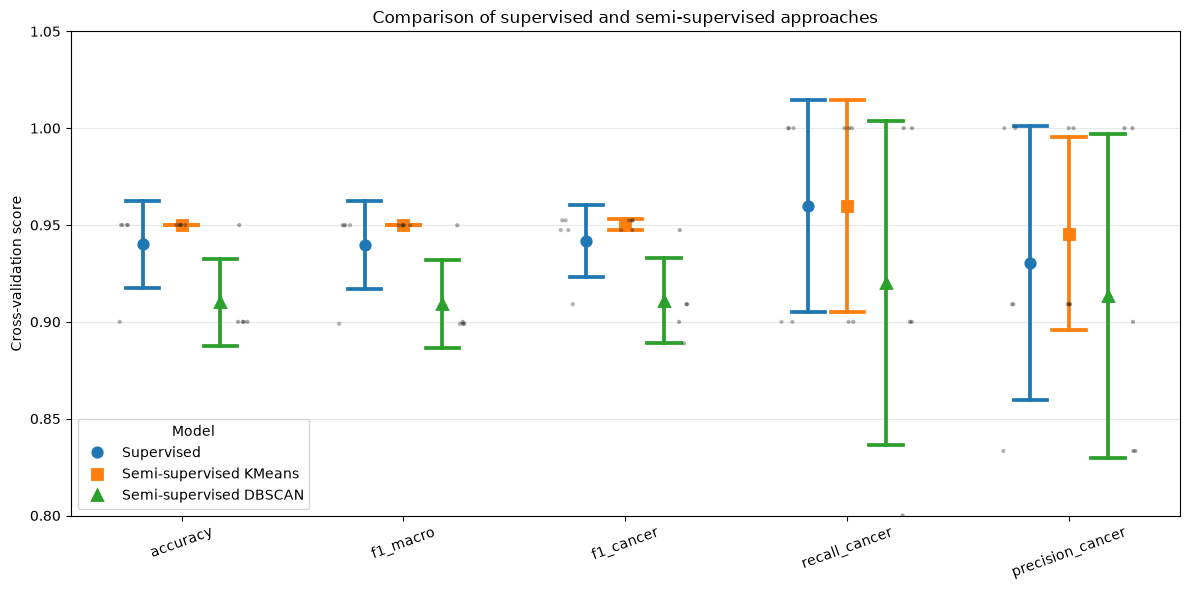

In [ ]:
metrics_to_plot = [
    "accuracy",
    "f1_macro",
    "f1_cancer",
    "recall_cancer",
    "precision_cancer",
]

cv_long = cv_results_df.melt(
    id_vars=["fold", "model"],
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 6))

ax = sns.pointplot(
    data=cv_long,
    x="metric",
    y="score",
    hue="model",
    dodge=0.35,
    errorbar="sd", # Afficher l'écart-type comme barre d'erreur
    markers=["o", "s", "^"],
    linestyles="",
    capsize=0.15,
)

# Afficher les valeurs individuelles
sns.stripplot(
    data=cv_long,
    x="metric",
    y="score",
    hue="model",
    dodge=True,
    color="black",
    alpha=0.35,
    size=3,
    legend=False,
)

ax.set_ylim(0.8, 1.05)
ax.set_xlabel("")
ax.set_ylabel("Cross-validation score")
ax.set_title("Comparison of supervised and semi-supervised approaches")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=20)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[:3],
    ["Supervised", "Semi-supervised KMeans", "Semi-supervised DBSCAN"],
    title="Model",
    loc="lower left",
)

plt.tight_layout()
plt.show()

### Interprétation de la validation croisée

La validation croisée montre un gain moyen modéré pour KMeans sélectif par rapport au modèle supervisé. Le gain est faible en valeur absolue, mais il est plus robuste avec un écart type inférieur.

DBSCAN reste inférieur à KMeans, malgré la pureté de ses clusters, probablement parce qu'il génère moins de pseudo-labels et couvre moins bien l'espace des données.

## Analyse de sensibilité du poids des pseudo-labels

Le poids des pseudo-labels contrôle leur influence pendant l'entraînement.

Un poids trop faible limite l'effet du semi-supervisé, tandis qu'un poids trop élevé peut amplifier les erreurs de pseudo-labellisation. On teste donc plusieurs valeurs de `pseudo_weight` pour vérifier si les pseudo-labels KMeans peuvent améliorer davantage les performances sans dégrader la robustesse du modèle.

In [16]:
pseudo_weight_values = [0.01, 0.05, 0.1, 0.2, 0.5]

weight_sensitivity_results = []

for pseudo_weight in pseudo_weight_values:
    config = KMEANS_CONFIG.copy()
    config["pseudo_weight"] = pseudo_weight

    fold_results = semi_supervised_selective_cv(
        strong_df,
        unknown_df,
        feature_columns,
        config=config,
        model_name=f"kmeans_weight_{pseudo_weight}",
    )

    weight_sensitivity_results.append(fold_results)

weight_sensitivity_df = pd.concat(weight_sensitivity_results, axis=0)

weight_sensitivity_summary = (
    weight_sensitivity_df
    .groupby("model")[[
        "accuracy",
        "f1_macro",
        "f1_cancer",
        "recall_cancer",
        "precision_cancer",
        "n_pseudo",
        "n_pseudo_cancer",
        "n_pseudo_normal",
        "n_selected_clusters",
    ]]
    .agg(["mean", "std"])
)

display(weight_sensitivity_df)
display(weight_sensitivity_summary)

,fold,model,accuracy,f1_macro,f1_cancer,recall_cancer,precision_cancer,n_pseudo,n_pseudo_cancer,n_pseudo_normal,n_selected_clusters,pseudo_weight,purity_threshold,min_labeled_per_cluster,clustering_method
0,1,kmeans_weight_0.01,0.95,0.949875,0.952381,1.0,0.909091,538,447,91,4,0.01,0.95,2,kmeans
1,2,kmeans_weight_0.01,0.95,0.949875,0.952381,1.0,0.909091,479,479,0,3,0.01,0.95,2,kmeans
2,3,kmeans_weight_0.01,0.95,0.949875,0.947368,0.9,1.000000,561,447,114,4,0.01,0.95,2,kmeans
3,4,kmeans_weight_0.01,0.95,0.949875,0.952381,1.0,0.909091,743,619,124,5,0.01,0.95,2,kmeans
4,5,kmeans_weight_0.01,0.95,0.949875,0.947368,0.9,1.000000,691,499,192,5,0.01,0.95,2,kmeans
0,1,kmeans_weight_0.05,0.95,0.949875,0.952381,1.0,0.909091,538,447,91,4,0.05,0.95,2,kmeans
1,2,kmeans_weight_0.05,0.90,0.898990,0.909091,1.0,0.833333,479,479,0,3,0.05,0.95,2,kmeans
2,3,kmeans_weight_0.05,0.95,0.949875,0.947368,0.9,1.000000,561,447,114,4,0.05,0.95,2,kmeans
3,4,kmeans_weight_0.05,0.95,0.949875,0.952381,1.0,0.909091,743,619,124,5,0.05,0.95,2,kmeans
4,5,kmeans_weight_0.05,0.95,0.949875,0.947368,0.9,1.000000,691,499,192,5,0.05,0.95,2,kmeans


accuracy            f1_macro           f1_cancer            \
                       mean       std      mean       std      mean       std   
model                                                                           
kmeans_weight_0.01     0.95  0.000000  0.949875  0.000000  0.950376  0.002745   
kmeans_weight_0.05     0.94  0.022361  0.939698  0.022756  0.941718  0.018410   
kmeans_weight_0.1      0.94  0.022361  0.939698  0.022756  0.941718  0.018410   
kmeans_weight_0.2      0.93  0.027386  0.929723  0.027596  0.931242  0.024666   
kmeans_weight_0.5      0.93  0.027386  0.929723  0.027596  0.931242  0.024666   

                   recall_cancer           precision_cancer            \
                            mean       std             mean       std   
model                                                                   
kmeans_weight_0.01          0.96  0.054772         0.945455  0.049793   
kmeans_weight_0.05          0.96  0.054772         0.930303  0.070743   
kmeans_weight_0.1           0.96  0.054772         0.930303  0.070743   
kmeans_weight_0.2           0.94  0.054772         0.928485  0.071537   
kmeans_weight_0.5           0.94  0.054772         0.928485  0.071537   

                   n_pseudo             n_pseudo_cancer             \
                       mean         std            mean        std   
model                                                                
kmeans_weight_0.01    602.4  110.348539           498.2  71.071795   
kmeans_weight_0.05    602.4  110.348539           498.2  71.071795   
kmeans_weight_0.1     602.4  110.348539           498.2  71.071795   
kmeans_weight_0.2     602.4  110.348539           498.2  71.071795   
kmeans_weight_0.5     602.4  110.348539           498.2  71.071795   

                   n_pseudo_normal            n_selected_clusters           
                              mean        std                mean      std  
model                                                                       
kmeans_weight_0.01           104.2  69.333974                 4.2  0.83666  
kmeans_weight_0.05           104.2  69.333974                 4.2  0.83666  
kmeans_weight_0.1            104.2  69.333974                 4.2  0.83666  
kmeans_weight_0.2            104.2  69.333974                 4.2  0.83666  
kmeans_weight_0.5            104.2  69.333974                 4.2  0.83666

### Influence du poids des pseudo-étiquettes

Afin d'évaluer l'impact des pseudo-étiquettes sur l'apprentissage semi-supervisé, plusieurs valeurs du paramètre `pseudo_weight` ont été testées. Ce paramètre contrôle l'importance accordée aux pseudo-échantillons par rapport aux données réellement annotées.

| Poids des pseudo-étiquettes | Accuracy | F1-macro | F1 Cancer | Recall Cancer | Precision Cancer |
|----------------------------:|---------:|---------:|----------:|---------------:|-----------------:|
| **0.01** | **0.95** | **0.950** | **0.950** | **0.96** | **0.945** |
| **0.05** | 0.94 | 0.940 | 0.942 | 0.96 | 0.930 |
| **0.10** | 0.94 | 0.940 | 0.942 | 0.96 | 0.930 |
| **0.20** | 0.93 | 0.930 | 0.931 | 0.94 | 0.928 |
| **0.50** | 0.93 | 0.930 | 0.931 | 0.94 | 0.928 |

Les meilleurs résultats sont obtenus avec un **poids très faible (`pseudo_weight = 0.01`)**. Cette configuration atteint une accuracy moyenne de **0.95** ainsi qu'un F1-score de **0.95**, tout en conservant un excellent rappel (**0.96**) pour la classe *Cancer*.

Lorsque le poids des pseudo-étiquettes augmente, les performances diminuent progressivement. À partir de `pseudo_weight = 0.20`, l'accuracy chute à **0.93** et le rappel de la classe *Cancer* passe de **0.96** à **0.94**.

Cette évolution s'explique par le fait que les pseudo-étiquettes, bien qu'utiles, restent des **étiquettes estimées** par l'algorithme de clustering et ne sont donc pas parfaitement fiables. Leur accorder un poids trop important conduit le modèle à apprendre davantage à partir de données potentiellement bruitées, ce qui dégrade sa capacité de généralisation.

À l'inverse, un faible poids permet aux pseudo-étiquettes de jouer un rôle de **complément d'information** sans remettre en cause l'influence des véritables annotations. Les données annotées demeurent la principale source d'apprentissage, tandis que les pseudo-étiquettes apportent une information supplémentaire qui améliore légèrement les performances.

Ces résultats montrent qu'en apprentissage semi-supervisé, **la qualité des pseudo-étiquettes est plus importante que leur influence**. Il est préférable de les utiliser avec un poids modéré plutôt que de les considérer au même niveau que les annotations réelles.

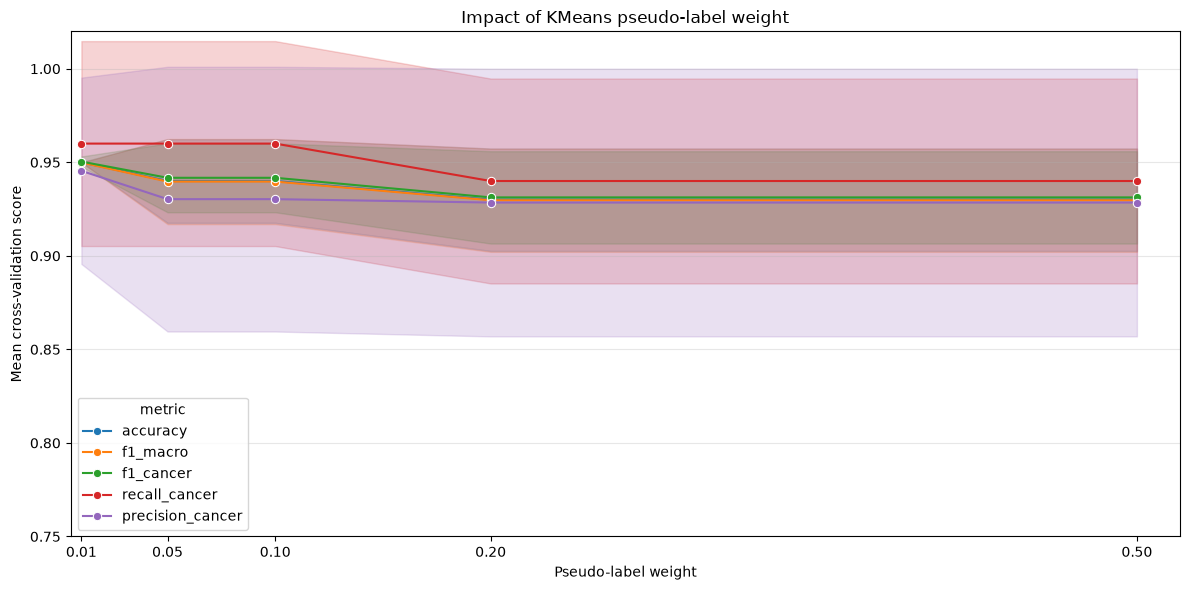

In [20]:
weight_plot_df = weight_sensitivity_df.melt(
    id_vars=["fold", "model", "pseudo_weight"],
    value_vars=[
        "accuracy",
        "f1_macro",
        "f1_cancer",
        "recall_cancer",
        "precision_cancer",
    ],
    var_name="metric",
    value_name="score",
)

weight_plot_df["pseudo_weight"] = weight_plot_df["pseudo_weight"].astype(float)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=weight_plot_df.sort_values("pseudo_weight"),
    x="pseudo_weight",
    y="score",
    hue="metric",
    marker="o",
    errorbar="sd",
)

ax.set_title("Impact of KMeans pseudo-label weight")
ax.set_xlabel("Pseudo-label weight")
ax.set_ylabel("Mean cross-validation score")

weights = sorted(weight_plot_df["pseudo_weight"].unique())
ax.set_xticks(weights)
ax.set_xticklabels([f"{w:.2f}" for w in weights])

# on enlève la marge automatique qui fait apparaître le 0
ax.set_xlim(min(weights) - 0.005, max(weights) + 0.02)

ax.set_ylim(0.75, 1.02)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interprétation du poids des pseudo-labels

L'analyse de sensibilité montre qu'augmenter le poids des pseudo-labels n'améliore pas les performances. Le poids faible `0.01` est donc conservé : les pseudo-labels apportent un signal complémentaire, mais ne doivent pas dominer les labels forts.

## Interprétation de la comparaison DBSCAN vs KMeans

DBSCAN confirme son intérêt pour isoler une zone `cancer` dense et pure. Sur le split final, DBSCAN sélectionne un cluster cancer pur et génère moins de pseudo-labels que KMeans.

Cependant, dans la validation croisée, cette pureté locale ne suffit pas à surpasser KMeans. KMeans sélectif reste meilleur en moyenne, car il sélectionne davantage de pseudo-labels, y compris des pseudo-labels `normal`, ce qui stabilise mieux la frontière de décision.

Conclusion : DBSCAN est utile comme comparaison semi-supervisée très conservatrice, mais dans cette configuration il ne remplace pas KMeans comme méthode principale.

In [18]:
# Sauvegardes
metrics_path = OUTPUT_DIR / "modeling_metrics_selective.csv"
cv_results_path = OUTPUT_DIR / "modeling_cv_results_selective.csv"
weight_sensitivity_path = OUTPUT_DIR / "pseudo_weight_sensitivity_kmeans.csv"

metrics_df.to_csv(metrics_path, index=False)
cv_results_df.to_csv(cv_results_path, index=False)
weight_sensitivity_df.to_csv(weight_sensitivity_path, index=False)

for model_name, result in semi_results.items():
    prefix = MODEL_CONFIGS[model_name]["method"]
    result["pseudo_labeled_df"].to_csv(
        OUTPUT_DIR / f"pseudo_labels_{prefix}_selective.csv",
        index=False,
    )
    result["semi_train_df"].to_csv(
        OUTPUT_DIR / f"semi_supervised_training_set_{prefix}_selective.csv",
        index=False,
    )
    result["cluster_stats"].to_csv(
        OUTPUT_DIR / f"{prefix}_cluster_purity_modeling.csv",
    )
    result["selected_clusters"].to_csv(
        OUTPUT_DIR / f"{prefix}_selected_clusters_modeling.csv",
    )

print("Final split metrics:", metrics_path)
print("CV results:", cv_results_path)
print("Pseudo-weight sensitivity:", weight_sensitivity_path)

Final split metrics: data\processed\modeling_metrics_selective.csv
CV results: data\processed\modeling_cv_results_selective.csv
Pseudo-weight sensitivity: data\processed\pseudo_weight_sensitivity_kmeans.csv


## Interprétation finale

La première version semi-supervisée utilisait tous les pseudo-labels KMeans. Cette approche était risquée car les pseudo-labels pouvaient dominer les vrais labels.

La version corrigée sélectionne uniquement des clusters très purs et pondère faiblement les pseudo-labels. La comparaison avec DBSCAN montre une nuance importante : une forte pureté locale ne garantit pas une meilleure performance finale.

Sur le split final 50/50, les modèles semi-supervisés obtiennent des performances équivalentes à la baseline supervisée. Le gain n'est donc pas visible sur ce découpage unique. En revanche, la validation croisée montre un gain moyen modéré pour KMeans sélectif, avec une meilleure stabilité que la baseline supervisée.

L'analyse de sensibilité montre qu'augmenter le poids des pseudo-labels n'améliore pas les performances. Le poids faible `0.01` est donc conservé : les pseudo-labels apportent un signal complémentaire, mais ne doivent pas dominer les labels forts.

Le message méthodologique est donc : le semi-supervisé peut aider, mais seulement si la pseudo-labellisation est contrôlée, testée sans fuite de données, et validée par les performances de classification.

## Definition of Done - étape 4

L'étape 4 est considérée comme terminée si :

- un split train/test stratifié est créé sur les données fortement labellisées ;
- le jeu de test n'est jamais utilisé pour générer les pseudo-labels ;
- un modèle supervisé est entraîné uniquement sur les labels forts ;
- les pseudo-labels sont générés uniquement pour les images `unknown` ;
- les labels forts ne sont jamais remplacés par des pseudo-labels ;
- KMeans sélectif est testé avec une règle de pureté ;
- DBSCAN sélectif est testé comme alternative orientée clusters denses et purs ;
- les pseudo-labels sont faiblement pondérés ;
- les modèles sont évalués sur le même jeu de test ;
- la comparaison principale est validée en cross-validation ;
- l'analyse de sensibilité du poids des pseudo-labels justifie le réglage retenu ;
- les métriques accuracy, precision, recall et F1-score sont comparées ;
- la classe `cancer` est analysée en priorité ;
- les résultats sont sauvegardés.